## Executive Summary

I build a full quantitative research pipeline for cross-sectional price momentum on the S&P 500. Using point-in-time WRDS/CRSP constituent data from 2000 onwards, I search over 2,000 parameter combinations and evaluate each strategy on four dimensions: Sharpe ratio, maximum drawdown, equity curve linearity, and time in market. The best configurations survive an out-of-sample walk-forward test and show statistically significant alpha net of transaction costs.

The pipeline has four stages:

| Stage | Description |
|---|---|
| Signal design | Rank assets by lookback return; go long winners, short losers |
| Grid search | Parallel evaluation of ~2,000 hyperparameter combinations |
| Walk-forward validation | 80/20 train/test split — test period never touched during development |
| Portfolio diagnostics | Factor attribution (FF5), tearsheet, parameter stability |

**Transaction costs** of 18 bps per unit of turnover ($\text{FEE} + \text{SLIPPAGE} = 15 + 3$ bps) are deducted before every performance metric. All Sharpe ratios and returns quoted below are net of these costs.

# Cross-Sectional Momentum — S&P 500

**Research Notebook** | Systematic Equity Strategy Research

This notebook documents a full quantitative research pipeline for discovering and validating cross-sectional momentum strategies on the S&P 500 universe. The workflow covers four stages:

1. **Signal design** — rank assets by their lookback return, go long recent winners and short (or ignore) recent losers
2. **Systematic search** — grid search over key hyperparameters, evaluated in parallel
3. **Walk-forward validation** — 80/20 train/test split to guard against in-sample overfitting
4. **Portfolio construction** — correlation-based clustering to select a diversified strategy set, followed by Monte Carlo mean-variance optimisation

*All performance figures are reported net of transaction costs. The test period was never used during strategy development. Point-in-time S&P 500 constituent data from WRDS/CRSP is used throughout to mitigate survivorship bias.*

![Selected strategy vs benchmark](imgs/MomentumUSASelectedStrategy.png)

In [2]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from tqdm import tqdm  # Use this in Jupyter
from joblib import Parallel, delayed

from utils.evaluate_strategy import evaluate_strategy, longest_drawdown, max_drawdown

import warnings
# ignore all
warnings.filterwarnings("ignore")

## Limitations & Further Considerations

### Data
- **Survivorship bias** — point-in-time S&P 500 constituent data from WRDS means only stocks that were *actually in the index on each date* are eligible, substantially reducing survivorship bias
- **Index additions/deletions** — any gaps or lags in the underlying CRSP coverage could still introduce a mild bias around reconstitution dates

### Execution
- **Slippage is flat** — real market impact scales with trade size relative to daily volume
- **Execution lag** — signals computed at close $t$ are assumed to trade at close $t+1$; in practice T+2 settlement applies
- **Short borrow cost** — not modelled; typically 25–100 bps/year for large-caps

### Strategy
- **No volatility targeting** — leverage is fixed; dynamic vol scaling would stabilise risk over time
- **No position limits** — individual weights can become unrealistically large in low-breadth regimes
- **Single train/test split** — a rolling walk-forward would give more robust out-of-sample evidence

## Motivation

Price momentum — the tendency for recent winners to continue outperforming recent losers — is one of the most replicated return premia in equity markets (Jegadeesh & Titman, 1993). The aim of this research is to:

- Confirm the signal exists in the **modern S&P 500** universe with realistic transaction costs applied
- Identify which parameter configurations produce the most **robust** edge, measured by the correlation between in-sample and out-of-sample Sharpe ratios
- Combine a decorrelated set of strategies into a single portfolio that is less sensitive to any one parameter choice

## 1. Universe & Data

**Universe:** Historical S&P 500 constituents sourced from **WRDS (Wharton Research Data Services)** using point-in-time CRSP data. Only stocks that were actually index members on each historical date are included, which substantially mitigates survivorship bias. Stocks are identified by `permno` — a permanent identifier that is stable across ticker changes and corporate events.

**Data:** Daily prices from CRSP, covering 2000 onwards and giving over two decades of history spanning the dot-com crash, GFC, and COVID drawdown.

To simplify rolling-window arithmetic, dates are stored as **fractional days since the Unix epoch**:

$$d_t = \frac{\text{Unix timestamp}_t}{86\,400}$$

This eliminates timezone edge cases and makes lookback offsets a simple integer subtraction.

In [3]:
# Load saved SP500 constituents data, by permno
sp500 = pd.read_csv("data/wrds_sp500_constituents.csv", index_col=0)

sp500.index = pd.to_datetime(sp500.index, errors="coerce", utc=True)
# make days since epoch (pandas 2.x stores datetimes as microseconds, so divide by 10**6 not 10**9)
sp500.index = (sp500.index.astype(int) / 10**6 / 86400.0)
sp500.columns = sp500.columns.astype(str)

sp500

,10006,10030,10049,10057,10078,10102,10104,10107,10108,10137,...,92988,93002,93089,93096,93132,93159,93246,93422,93429,93436
10957.0,False,False,False,False,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10958.0,False,False,False,False,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10959.0,False,False,False,False,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10960.0,False,False,False,False,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10961.0,False,False,False,False,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20630.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20631.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20632.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20633.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# Load saved data which we got from WRDS (Wharton Research Data Services)
directory = "data/wrds_data"
files = [f for f in os.listdir(directory) if f.endswith(".csv")]

dfs = []
for file in tqdm(files):
    df = pd.read_csv(os.path.join(directory, file))
    dfs.append(df)

prices_df = pd.concat(dfs, ignore_index=True)
prices_df["price"] = prices_df["prc"].astype(float)
prices_df["symbol"] = prices_df["permno"].astype(str)
prices_df["date"] = pd.to_datetime(prices_df["date"], errors="coerce", utc=True).dt.tz_localize(None)

# Make date days since epoch (pandas 2.x stores datetimes as microseconds, so divide by 10**6 not 10**9)
prices_df["date"] = prices_df["date"].astype(int) / 10**6 / 86400.0
prices_df

100%|██████████| 1935/1935 [00:01<00:00, 1163.55it/s]


,permno,date,prc,ret,price,symbol
0,27633,10959.0,23.625,-0.033248,23.6250,27633
1,27633,10960.0,22.3125,-0.055556,22.3125,27633
2,27633,10961.0,22.75,0.019608,22.7500,27633
3,27633,10962.0,24.625,0.082418,24.6250,27633
4,27633,10963.0,25.125,0.020305,25.1250,27633
...,...,...,...,...,...,...
4894176,22752,20081.0,99.45,0.000805,99.4500,22752
4894177,22752,20083.0,99.87,0.004223,99.8700,22752
4894178,22752,20084.0,99.7,-0.001702,99.7000,22752
4894179,22752,20087.0,98.37,-0.01334,98.3700,22752


In [5]:
# Price wide
price_wide = prices_df.pivot(index="date", columns="symbol", values="price").sort_index()
price_wide.tail()

symbol,10078,10104,10107,10108,10137,10138,10145,10147,10225,10299,...,92988,93002,93089,93096,93132,93159,93246,93422,93429,93436
date,,,,,,,,,,,,,,,,,,,,,
20081.0,NaN,171.41000,439.32999,NaN,NaN,117.07,228.89999,NaN,NaN,NaN,...,NaN,239.67999,278.54999,74.64,97.81,NaN,154.70000,NaN,194.41000,462.28
20083.0,NaN,171.67999,438.10999,NaN,NaN,117.58,231.86000,NaN,NaN,NaN,...,NaN,245.36000,278.38000,75.63,97.29,NaN,156.02000,NaN,196.55000,454.13
20084.0,NaN,168.96001,430.53000,NaN,NaN,115.67,229.50999,NaN,NaN,NaN,...,NaN,241.75000,277.29999,75.89,96.08,NaN,155.67000,NaN,197.23000,431.66
20087.0,NaN,166.91000,424.82999,NaN,NaN,113.86,226.60001,NaN,NaN,NaN,...,NaN,235.58000,275.73999,75.69,95.13,NaN,154.74001,NaN,195.92999,417.41
20088.0,NaN,166.64000,421.50000,NaN,NaN,113.09,225.89000,NaN,NaN,NaN,...,NaN,231.84000,275.42999,75.82,94.48,NaN,155.05000,NaN,195.39999,403.84


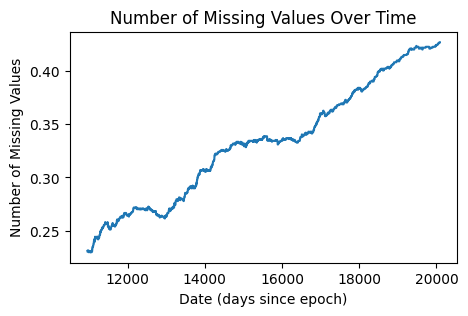

In [6]:
# Inspect number of missing values per row over time
missing_counts = price_wide.isna().mean(axis=1)
plt.figure(figsize=(5, 3))
sns.lineplot(x=price_wide.index, y=missing_counts)
plt.title("Number of Missing Values Over Time")
plt.xlabel("Date (days since epoch)")
plt.ylabel("Number of Missing Values")
plt.show()

In [7]:
# days
days = price_wide.index.max() - price_wide.index.min()
print(f"Total days: {days}")
print(f"Total years: {days / 365:.2f}")

Total days: 9129.0
Total years: 25.01


In [8]:
# Define the benchmark as the equal weighted average of buy and hold at day 1.
# It gets the daily return if the symbol is in the sp500

# sp500 is a pivoted table with columns=permno, index=date, value=bool
# price_wide is a pivoted table with columns=symbol, index=date, value=price

# Align sp500 membership mask to price_wide (matching dates and symbols)
sp500_mask = sp500.reindex(index=price_wide.index, columns=price_wide.columns).fillna(False).astype(bool)

# Daily returns
daily_returns = price_wide.pct_change(fill_method=None)

# Mask returns to only include symbols that are in the S&P 500 on that date
masked_returns = daily_returns.where(sp500_mask, np.nan)

# Equal-weighted benchmark: mean across constituents each day
benchmark = masked_returns.mean(axis=1).fillna(0.0)
benchmark

date
10959.0    0.000000
10960.0   -0.026535
10961.0    0.004525
10962.0    0.011116
10963.0    0.022910
             ...   
20081.0    0.007806
20083.0    0.000959
20084.0   -0.007175
20087.0   -0.009896
20088.0    0.001414
Length: 6289, dtype: float64

The **equal-weighted daily return** of all available constituents serves as our passive benchmark:

$$r^{\text{bench}}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} r_{i,t}$$

where $N_t$ is the number of assets with available data on day $t$. Any strategy that cannot beat this is simply harvesting passive equity beta — not a meaningful alpha source.

## 2. Evaluation Metrics & Strategy Design

Before running the grid search, I define the helper functions used to evaluate each strategy and the `run_strategy` function itself. This section also contains a detailed write-up of the signal construction methodology.

##### Linear R-squared

I build a log equity curve based on the mean average. And then I get the r-squared between the supposed mean curve against the actual equity curve. If the returns are constant across time, then I will get a higher r-squared, suggesting that the returns are not as time-dependent.

In [9]:
# Measure linearity
def linear_r2(series):
    # Make it into cumprod
    cumprod = np.cumprod(1+series)
    # natural log
    log_cumprod = np.log(cumprod)
    # Now get the r2 of a linear fit
    x = np.arange(len(log_cumprod))
    y = log_cumprod.values
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    y_fit = m * x + c
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

## Strategy Methodology

### Universe
Historical S&P 500 constituents from WRDS/CRSP with point-in-time membership. On each date $t$, only stocks that were actually index members are eligible for ranking and position-taking.

### Signal Generation

**Lookback Return** — for each asset $i$ at time $t$:

$$r^{lb}_{i,t} = \frac{P_{i,t - s}}{P_{i,t - L}} - 1$$

where $L$ = `lookback_rows` and $s$ = `skip_rows` (optional reversal buffer, e.g. 21 days to skip the short-term reversal). Assets are ranked by $r^{lb}$ each day as a percentile $[0, 1]$.

**Position**

$$\text{pos}_{i,t} = \begin{cases} +1 & \text{if rank} > 1-q \quad \text{(winners)} \\ -1 & \text{if rank} < q \quad \text{(losers)} \\ 0 & \text{otherwise} \end{cases}$$

### Optional Filters

| Filter | Description |
|---|---|
| `momentum_min_return` | Drop position if annualised lookback return is below threshold |
| `short_lookback_window` | Require agreement between long and short window signals |
| `vol_scale` | Scale raw positions by $1/\sigma_i$ before normalisation |
| `residual_momentum` | Remove equal-weighted market return before ranking (idiosyncratic signal) |
| `market_filter` | Zero all positions when the equal-weighted index is in drawdown > 10% |

### Cohort-Based Staggering

To avoid concentrating all rebalancing on one day, I split positions into $N_c = \lfloor H / S \rfloor$ cohorts updated on a round-robin cycle:

$$\tilde{w}_{i,t} = \frac{1}{N_c} \sum_{k=1}^{N_c} \text{pos}^{(k)}_{i,t}$$

### Weight Normalisation

Equal weight (default): $w_{i,t} = \tilde{w}_{i,t} \,/\, \sum_j |\tilde{w}_{j,t}|$

Lookback-weighted: $w_{i,t} \propto \tilde{w}_{i,t} \cdot \log\!\left(1 + |r^{lb}_{i,t}|\right)$, which gives larger allocations to stocks with stronger signals.

### Transaction Costs

$$\text{cost}_{i,t} = \left|\Delta w_{i,t}\right| \times (\text{FEE} + \text{SLIPPAGE})$$

with FEE = 15 bps (Trading 212 FX spread) and SLIPPAGE = 3 bps (bid-ask, S&P 500 large-caps).

### PnL

$$r^{\text{port}}_t = \sum_i \left( w_{i,t} \cdot r^{fwd}_{i,t} - \text{cost}_{i,t} \right) \times \text{leverage}$$

where $r^{fwd}_{i,t} = P_{i,t+1}/P_{i,t} - 1$ is the next-day return, avoiding any look-ahead bias.

In [10]:
START_DATE = price_wide.index.min()
# START_DATE = price_wide.index.max() - (252 * 12)
START_DATE = int(START_DATE)

**Transaction costs** are modelled as **15 bps per unit of weight turnover** — the FX spread Trading 212 charges on US equities. For each asset $i$ at time $t$:

$$\text{cost}_{i,t} = \left| w_{i,t} - w_{i,t-1} \right| \times 0.0015$$

Costs are vectorised across the full weight matrix and subtracted before summing portfolio returns. This captures both entry and exit friction and penalises high-turnover configurations in the grid search.

> **Note:** Only **commission fees** have been modelled at this stage. **Market impact and bid-ask slippage are not yet accounted for.** For a large-cap universe like the S&P 500, slippage is expected to be modest at typical position sizes, but live performance would likely trail backtested results by a small additional margin. Incorporating a slippage model is a natural next step before live deployment.

The backtest window covers **12 years** prior to the most recent observation — enough history for a meaningful walk-forward split without anchoring results to pre-GFC market structure.

In [11]:

# Trading212 (US FX 0.15%)
FEE      = 0.00_15   # broker FX spread per unit turnover
SLIPPAGE = 0.00_03   # ~3 bps round-trip bid-ask, S&P 500 large-caps

def run_strategy(lookback_window
                 , trade_window
                 , q
                 , leverage
                 , momentum=True
                 , shorting=True
                 , long=True
                 , momentum_min_return=False
                 , short_lookback_window=False
                 , start_date=False
                 , weight_by_lookback=False
                 , staggering_interval=1
                 , skip_days=False
                 , vol_scale=False
                 , market_filter=False
                 , residual_momentum=False
                 , log=False
                 , vol_target=None      # annualised portfolio vol target, e.g. 0.10 = 10%
                 ):

    # --- Basic time scaling ---
    time_delta_mins = int((price_wide.index[-1] - price_wide.index[-2]) * 24 * 60)
    lookback_rows   = (lookback_window * 60) // time_delta_mins
    trade_window    = (trade_window * 60) // time_delta_mins
    skip_rows       = (skip_days * 60) // time_delta_mins if skip_days is not False else 0

    if short_lookback_window is not False:
        short_lookback_rows = (short_lookback_window * 60) // time_delta_mins
    else:
        short_lookback_rows = None

    # --- Local copies ---
    lcl_price_wide = price_wide.copy()

    # ===================== SP500 MEMBERSHIP MASK =====================
    sp500_mask = sp500.reindex(index=lcl_price_wide.index, columns=lcl_price_wide.columns).fillna(False).astype(bool)

    if start_date is not False:
        start_date = float(start_date)

    # ===================== SIGNAL GENERATION =====================
    # skip_rows: exclude most recent period (e.g. 21 days to avoid short-term reversal)
    long_lookback_wide = lcl_price_wide.shift(skip_rows) / lcl_price_wide.shift(lookback_rows) - 1

    # Residual momentum: remove equal-weighted market return so we rank idiosyncratic performance
    if residual_momentum:
        mkt_lookback = long_lookback_wide.mean(axis=1)
        long_lookback_wide = long_lookback_wide.sub(mkt_lookback, axis=0)

    # Only rank symbols that are currently in the S&P 500
    long_lookback_wide = long_lookback_wide.where(sp500_mask, np.nan)

    ranked_wide = long_lookback_wide.rank(axis=1, method="first", pct=True)

    # ranked_wide near 1.0 = top performers (winners), near 0.0 = bottom performers (losers)
    pos_arr = np.zeros(ranked_wide.shape, dtype=float)
    if momentum:
        # Momentum: long winners (top q%), short losers (bottom q%)
        pos_arr = np.where(ranked_wide > (1 - q),  1.0, pos_arr)  # top q%    -> long
        pos_arr = np.where(ranked_wide < q,        -1.0, pos_arr)  # bottom q% -> short
    else:
        # Mean reversion: long losers (bottom q%), short winners (top q%)
        pos_arr = np.where(ranked_wide < q,         1.0, pos_arr)  # bottom q% -> long
        pos_arr = np.where(ranked_wide > (1 - q),  -1.0, pos_arr)  # top q%    -> short

    pos_wide = pd.DataFrame(pos_arr, index=lcl_price_wide.index, columns=lcl_price_wide.columns)

    if not shorting:
        pos_wide = pos_wide.where(pos_wide > 0, 0.0)
    if not long:
        pos_wide = pos_wide.where(pos_wide < 0, 0.0)

    if momentum_min_return is not False:
        # Geometric annualisation: (1 + r_lookback)^(252 / lookback_days) - 1
        lookback_window_days = lookback_window / 24
        ann_momentum_wide = (1 + long_lookback_wide) ** (252 / lookback_window_days) - 1
        pos_wide = pos_wide.where(
            ((pos_wide ==  1) & (ann_momentum_wide >  momentum_min_return)) |
            ((pos_wide == -1) & (ann_momentum_wide < -momentum_min_return)),
            0.0
        )

    if short_lookback_rows is not None:
        short_lookback_wide = lcl_price_wide / lcl_price_wide.shift(short_lookback_rows) - 1
        same_sign = (np.sign(long_lookback_wide) * np.sign(short_lookback_wide)) > 0
        pos_wide = pos_wide.where(same_sign, 0.0)

    # Zero out positions for symbols not in S&P 500 on that date
    pos_wide = pos_wide.where(sp500_mask, 0.0)

    if start_date is not False:
        pos_wide.loc[pos_wide.index < start_date] = 0.0

    # ===================== VOLATILITY SCALING =====================
    if vol_scale:
        # Scale each position by 1/vol — lower vol stocks get larger weight after normalisation
        vol_window  = (63 * 60) // time_delta_mins
        rolling_vol = lcl_price_wide.pct_change(fill_method=None).rolling(vol_window, min_periods=1).std()
        rolling_vol = rolling_vol.replace(0, np.nan)
        pos_wide    = pos_wide.div(rolling_vol).replace([np.inf, -np.inf], 0.0).fillna(0.0)
        pos_wide    = pos_wide.where(sp500_mask, 0.0)

    # ===================== COHORT-BASED STAGGERING =====================
    H = max(1, int(trade_window))
    S = max(1, int(staggering_interval))

    n_idx, n_assets = len(pos_wide), pos_wide.shape[1]
    stag_pos_arr = np.zeros((n_idx, n_assets), dtype=float)

    if start_date is not False:
        idx_vals  = pos_wide.index.values.astype(float)
        mask      = idx_vals >= start_date
        start_idx = int(np.argmax(mask)) if mask.any() else n_idx
    else:
        start_idx = 0

    num_cohorts   = max(1, H // S)
    cohort_matrix = np.zeros((num_cohorts, n_assets), dtype=float)
    pos_arr_full  = pos_wide.to_numpy(dtype=float)

    sp500_mask_arr = sp500_mask.to_numpy(dtype=bool)

    for t in range(start_idx, n_idx):
        offset = t - start_idx
        if offset % S == 0:
            cohort_id = (offset // S) % num_cohorts
            cohort_matrix[cohort_id, :] = pos_arr_full[t]

        mean_pos = cohort_matrix.mean(axis=0)

        # If a symbol has exited the S&P 500 at time t, force its staggered position to 0
        mean_pos[~sp500_mask_arr[t]] = 0.0

        stag_pos_arr[t] = mean_pos

    stag_pos_wide = pd.DataFrame(stag_pos_arr, index=pos_wide.index, columns=pos_wide.columns)

    # ===================== WEIGHT NORMALISATION =====================
    if weight_by_lookback:
        lb_returns     = long_lookback_wide.reindex_like(stag_pos_wide).fillna(0.0)
        lb_weights     = np.log1p(np.abs(lb_returns))
        signed_weights = stag_pos_wide * lb_weights
        abs_sum        = signed_weights.abs().sum(axis=1)
        weight_wide    = signed_weights.div(abs_sum, axis=0).fillna(0.0)
    else:
        abs_sum     = stag_pos_wide.abs().sum(axis=1)
        weight_wide = stag_pos_wide.div(abs_sum, axis=0).fillna(0.0)

    if start_date is not False:
        weight_wide.loc[weight_wide.index < start_date] = 0.0

    # ===================== MARKET CRASH FILTER =====================
    if market_filter:
        # Zero all positions when equal-weighted S&P 500 is in drawdown > 10%
        mkt_ret = lcl_price_wide.pct_change(fill_method=None).mean(axis=1)
        mkt_cum = (1 + mkt_ret).cumprod()
        mkt_dd  = mkt_cum / mkt_cum.cummax() - 1
        in_crash = (mkt_dd < -0.10)
        weight_wide.loc[in_crash] = 0.0

    # Next-period returns
    pct_wide = lcl_price_wide.pct_change(fill_method=None).shift(-1).fillna(0.0)

    # ===================== TRANSACTION COSTS + SLIPPAGE (VECTORISED) =====================
    delta_w_wide = weight_wide.diff()

    if start_date is not False:
        idx_vals        = weight_wide.index.values.astype(float)
        mask            = idx_vals >= start_date
        first_trade_idx = int(np.argmax(mask)) if mask.any() else len(weight_wide)
    else:
        first_trade_idx = 0

    delta_w_wide.iloc[:first_trade_idx] = 0.0
    delta_w_wide.iloc[first_trade_idx]  = weight_wide.iloc[first_trade_idx].abs()

    abs_delta     = delta_w_wide.abs()
    # Broker FX fee + bid-ask slippage, both applied to turnover
    cost_wide     = abs_delta * (float(FEE) + float(SLIPPAGE))
    delta_w_daily = abs_delta.sum(axis=1)

    if log:
        avg_to  = delta_w_daily.mean()
        ann_fee = avg_to * (FEE + SLIPPAGE) * 365
        print(f"Average daily turnover (sum |Δw|): {avg_to:.6f}")
        print(f"Estimated annual cost drag:        {ann_fee*100:.3f}%")

    # ===================== PNL =====================
    wret_wide   = (pct_wide * weight_wide) - cost_wide
    wret_wide  *= leverage
    wret_series = wret_wide.sum(axis=1)

    if start_date is not False:
        wret_series = wret_series.loc[wret_series.index >= start_date]

    # ===================== VOLATILITY TARGETING =====================
    if vol_target is not None:
        # Use yesterday's 63-day realised vol to scale today's exposure.
        # Clip leverage multiplier to [0.25, 4×] to prevent blow-ups.
        roll_vol   = wret_series.rolling(63, min_periods=10).std() * np.sqrt(365)
        lev_scale  = (vol_target / roll_vol.shift(1)).clip(0.25, 4.0).fillna(1.0)
        wret_series = wret_series * lev_scale
        if log:
            print(f"Vol target: {vol_target:.0%} | avg leverage: {lev_scale.mean():.2f}x | "
                  f"realised vol: {wret_series.std()*np.sqrt(365):.2%}")

    return wret_series.fillna(0.0)


## 3. Prototype Validation

Before running the full grid search, I run a single representative parameter set to validate the pipeline end-to-end. This is important: it catches look-ahead bias, cost calculation errors, or benchmark misalignment before scaling to hundreds of strategies. A clean equity curve here confirms the mechanics are correct.

Average daily turnover (sum |Δw|): 0.083862
Estimated annual cost drag:        5.510%


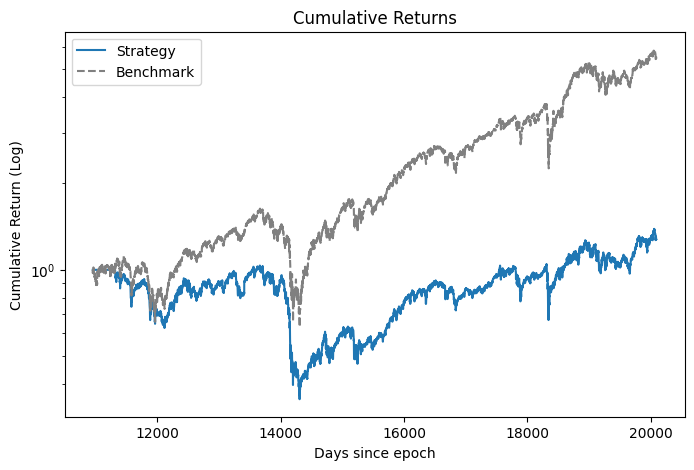

             PERFORMANCE             
-------------------------------------
Final Return                : 27.74%
Avg Daily Return            : 0.01%
Median Daily Return         : 0.01%
Stddev Return               : 1.29%
Annualized Return           : 4.56%
Annualized Sharpe Ratio     : 0.18
Max Drawdown                : -63.89%
Longest Drawdown (days)     : 729
Win Rate                    : 52.68%
Skewness                    : -0.21
Kurtosis                    : 9.08
Days                        : 6289
Days in Trade               : 95.99%


In [12]:
r = run_strategy(
    lookback_window=24*252,
    skip_days=21*24,
    trade_window=24*5, 
    leverage=1.0,
    q=0.3,
    momentum=True,
    shorting=False,
    # momentum_min_return=1.0,
    long=True,
    start_date=START_DATE,
    log=True,
    weight_by_lookback=True
)

bnch = benchmark.loc[r.index]

plt.figure(figsize=(8, 5))
plt.plot(np.cumprod(1+r), label="Strategy")
plt.plot(np.cumprod(1+bnch), label="Benchmark", color="gray", linestyle="--")
plt.title("Cumulative Returns")
plt.ylabel("Cumulative Return (Log)")
plt.xlabel("Days since epoch")
plt.legend()
plt.yscale("log")
plt.show()

evaluate_strategy(r)

## 4. Systematic Parameter Search

With the pipeline validated, I now search over the following dimensions of the parameter space:

| Hyperparameter | Values tested |
|---|---|
| Lookback window | 180, 360, 540, 720 calendar days |
| Rebalance window | 1, 5, 10, 30 days |
| Percentile cut $q$ | 0.5%, 1%, 2.5%, 5%, 10% |
| Min. annualised return filter | 0%, 50% |
| Short-window confirmation | None, 30d, 90d |

Two structural constraints keep the search space economically sensible:
- $L_{\text{lookback}} \geq 2 \times W_{\text{rebalance}}$ — the signal window is always wider than the holding period
- Either the long or short leg must be active (no empty strategies)

Each valid combination is treated as an independent strategy and evaluated in parallel using `joblib`.

In [13]:
lookback_window_list    = [24*126, 24*252, 24*378, 24*504]   # 6, 12, 18, 24 months (classic momentum windows)
trade_window_list       = [24*5, 24*21, 24*63]               # weekly, monthly, quarterly rebalance
q_list                  = [0.1, 0.2, 0.3]                    # wider cuts — more breadth, more robust
leverage_list           = [1.0]
momentum_list           = [True, False]  # False = mean reversion, but only useful long-only
shorting_list           = [False, True]
long_list               = [True]
mom_min_ret_list        = [False, 0.0, 0.5]                  # no filter, 0% threshold, 50% annualised
short_lookback_list     = [False, 24*21]                     # no confirmation, or 1-month confirmation
start_date_list         = [START_DATE]
weight_lookback_list    = [False, True]
skip_days_list          = [False, 24*5, 24*21]               # no skip, 1-week, 1-month
vol_scale_list          = [False, True]                      # inverse-vol position sizing
market_filter_list      = [False, True]                      # zero out positions in market crash >10% dd
residual_mom_list       = [False, True]                      # idiosyncratic momentum (remove market return)


In [14]:
# Index price_wide to START_DATE - max(lookback/24)
start_idx = START_DATE - (max(lookback_window_list) // 24)
price_wide = price_wide.loc[price_wide.index >= start_idx]

In [15]:
args = product(lookback_window_list, trade_window_list, q_list, leverage_list,
               momentum_list, shorting_list, long_list, mom_min_ret_list,
               short_lookback_list, start_date_list, weight_lookback_list, skip_days_list,
               vol_scale_list, market_filter_list, residual_mom_list)
args = list(args)

# lookback has to be more or equal to trade window
args = [a for a in args if a[0] >= a[1]]
# either long or short has to be true
args = [a for a in args if a[5] or a[6]]
# lookback has to be at least twice the trade period
args = [a for a in args if a[0] >= 2 * a[1]]
# short_lookback must be shorter than main lookback
args = [a for a in args if a[8] is False or a[8] < a[0]]
# Add a filter in the args construction to drop the redundant mirrors:
args = [a for a in args if not (a[4] == False and a[5] == True)]  # drop: mean-reversion + shorting

np.random.shuffle(args)

args = args[:2000]
print(f"Total valid combinations: {len(args)}")

Total valid combinations: 2000


In [16]:
# Choose how many workers (CPU cores) you want, -1 = all cores
n_jobs = 6         # or e.g. 4
backend = "loky"    # "loky" = processes, "threading" = threads

rolling_dfs = Parallel(n_jobs=n_jobs, backend=backend)(
    delayed(run_strategy)(*arg) for arg in tqdm(args)
)

rolling_df = pd.concat(rolling_dfs, axis=1)
rolling_df = rolling_df.fillna(0)

# Get the max lookback window, then start from there
time_delta_mins = int((price_wide.index[-1] - price_wide.index[-2]) * 24 * 60) 
max_lookback = max(lookback_window_list)
start_idx = int((max_lookback * 60) // time_delta_mins)
rolling_df = rolling_df.iloc[start_idx:]
rolling_df

100%|██████████| 2000/2000 [05:10<00:00,  6.45it/s]


,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
date,,,,,,,,,,,,,,,,,,,,,
11695.0,0.005732,0.000000,0.0,0.0,0.0,0.012905,0.000000,0.0,0.0,-0.003657,...,0.002797,0.0,-0.003057,0.0,0.0,-0.008027,-0.000587,-0.006032,0.0,-0.003585
11696.0,-0.016315,0.000000,0.0,0.0,0.0,-0.024427,0.000000,0.0,0.0,-0.000102,...,-0.001730,0.0,-0.012142,0.0,0.0,0.012187,0.001794,-0.006473,0.0,-0.003220
11697.0,-0.010910,0.000000,0.0,0.0,0.0,-0.007767,0.000000,0.0,0.0,-0.002728,...,0.010535,0.0,-0.001298,0.0,0.0,-0.007408,0.005285,-0.020094,0.0,-0.002377
11698.0,-0.002406,0.000000,0.0,0.0,0.0,-0.024126,0.000000,0.0,0.0,-0.009277,...,0.012907,0.0,-0.008955,0.0,0.0,-0.004056,0.008954,-0.022640,0.0,-0.003271
11701.0,0.015627,0.000000,0.0,0.0,0.0,0.000992,0.000000,0.0,0.0,0.008511,...,-0.001517,0.0,0.003656,0.0,0.0,0.007038,0.003119,0.006951,0.0,0.004091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20081.0,-0.002479,-0.001402,0.0,0.0,0.0,-0.000346,-0.002301,0.0,0.0,-0.000321,...,-0.001237,0.0,-0.000496,0.0,0.0,0.000346,-0.001272,0.002110,0.0,-0.001323
20083.0,-0.004925,-0.008980,0.0,0.0,0.0,-0.000946,-0.006600,0.0,0.0,-0.010485,...,-0.007934,0.0,-0.011255,0.0,0.0,-0.000962,-0.000236,-0.006810,0.0,-0.008388
20084.0,-0.002343,-0.005484,0.0,0.0,0.0,-0.010113,-0.000873,0.0,0.0,-0.010838,...,-0.005363,0.0,-0.007335,0.0,0.0,0.006251,0.000422,-0.013769,0.0,-0.003930


## 5. Walk-Forward Validation

The strategy return matrix has shape $(T \times N_{\text{strategies}})$. I split it **80% train / 20% test** by time — the test window is a contiguous, out-of-sample block at the end of history. All selection and filtering decisions below are made **exclusively on the training period**.

For each strategy $s$, the following metrics are computed on the training window:

| Metric | Formula | What it measures |
|---|---|---|
| Annualised Sharpe | $\dfrac{\bar{r}_s \cdot 365}{\sigma_s \sqrt{365}}$ | Risk-adjusted return |
| Max drawdown | $\max_t\!\left(1 - \dfrac{V_t}{\max_{u \le t} V_u}\right)$ | Worst peak-to-trough loss |
| Equity linearity $R^2$ | OLS on $\ln\!\prod(1 + r_s)$ vs time | Time-consistency of the edge |
| Trading days ratio | $\frac{\text{days with } r \neq 0}{T}$ | How often the strategy is active |

The goal is to select strategies that score well on **all four** dimensions, not just Sharpe in isolation.

In [17]:
test_split = 0.2
# Divide into train/test series
test_split_idx = int(len(rolling_df) * test_split)

train_rolling_df = rolling_df.iloc[:-test_split_idx]
test_rolling_df = rolling_df.iloc[-test_split_idx:]

# Get mean and std for each column across both periods
train_mean = train_rolling_df.mean()
train_std = train_rolling_df.std()
test_mean = test_rolling_df.mean()
test_std = test_rolling_df.std()
train_sharpe = (train_mean * 365 ) / (train_std * np.sqrt(365))
test_sharpe = (test_mean * 365 ) / (test_std * np.sqrt(365))

# drop nan in both, then intersect index again
# train_sharpe = train_sharpe.dropna()
# test_sharpe = test_sharpe.dropna()
common_idx = train_sharpe.index.intersection(test_sharpe.index)
train_sharpe = train_sharpe.loc[common_idx]
test_sharpe = test_sharpe.loc[common_idx]

In [18]:
# Best strategy based on train sharpe
train_tf = train_rolling_df.unstack().reset_index()
train_tf.columns = ["strategy", "datetime", "return"]

test_tf = test_rolling_df.unstack().reset_index()
test_tf.columns = ["strategy", "datetime", "return"]

# Group by strategy
train_strt = train_tf.groupby("strategy")["return"].agg(["mean", "std"]).reset_index()
test_strt = test_tf.groupby("strategy")["return"].agg(["mean", "std"]).reset_index()

train_strt["sharpe"] = (train_strt["mean"] / train_strt["std"]) * np.sqrt(365)
test_strt["sharpe"] = (test_strt["mean"] / test_strt["std"]) * np.sqrt(365)

# Now join so we get strategy, sharpe train, sharpe test
combined_strt = train_strt.merge(test_strt, on="strategy", suffixes=("_train", "_test"))
combined_strt = combined_strt[["strategy", "sharpe_train", "sharpe_test"]]

combined_strt.sort_values(by="sharpe_train", ascending=False).head(10)

,strategy,sharpe_train,sharpe_test
1831,1831,0.703636,0.798503
955,955,0.623807,0.802284
1827,1827,0.623807,0.802284
818,818,0.623807,0.802284
532,532,0.623807,0.802284
502,502,0.623807,0.802284
190,190,0.604286,0.929542
1271,1271,0.603435,0.740156
454,454,0.592646,0.843005
533,533,0.582088,0.843005


In [19]:
# Get max drawdown per column
train_dd = train_rolling_df.apply(max_drawdown)
test_dd = test_rolling_df.apply(max_drawdown)

In [20]:
# Get longest drawdown per column
train_lgdd = train_rolling_df.apply(longest_drawdown)
test_lgdd = test_rolling_df.apply(longest_drawdown)

In [21]:
# days in trading, non-zero / total
def trading_days_ratio(series):
    non_zero_days = (series != 0).sum()
    total_days = len(series)
    return non_zero_days / total_days

train_tdr = train_rolling_df.apply(trading_days_ratio)
test_tdr = test_rolling_df.apply(trading_days_ratio)

In [22]:
names = [
    "lookback_window",
    "trade_window",
    "q",
    "leverage",
    "momentum",
    "shorting",
    "long",
    "min_momentum",
    "short_lookback_window",
    "start_date",
    "weight_by_lookback",
    "skip_days",
    "vol_scale",
    "market_filter",
    "residual_momentum",
]


In [23]:
# Make a dataframe with the sharpe for test and train plus all of the args
df = pd.DataFrame(columns=names + ["sharpe_train", "sharpe_test"])
df[names] = [a for a in args]

df["sharpe_train"] = train_sharpe.values
df["sharpe_test"] = test_sharpe.values

df["max_drawdown_train"] = train_dd.values
df["max_drawdown_test"] = test_dd.values

df["long_drawdown_train"] = train_lgdd.values
df["long_drawdown_test"] = test_lgdd.values

df["avg_train"] = train_rolling_df.mean().values
df["avg_test"] = test_rolling_df.mean().values

df["linear_train"] = train_rolling_df.apply(linear_r2).values
df["linear_test"] = test_rolling_df.apply(linear_r2).values

df["days_train"] = len(train_rolling_df)
df["days_test"] = len(test_rolling_df)

df["trading_days_ratio_train"] = train_tdr.values
df["trading_days_ratio_test"] = test_tdr.values

df["min_dly_return_train"] = train_rolling_df.min().values
df["min_dly_return_test"] = test_rolling_df.min().values


df["train_score"] = df["sharpe_train"] * (1 - df["max_drawdown_train"]) * df["linear_train"]
df["test_score"] = df["sharpe_test"] * (1 - df["max_drawdown_test"]) * df["linear_test"]

df.describe()

,sharpe_train,sharpe_test,max_drawdown_train,max_drawdown_test,long_drawdown_train,long_drawdown_test,avg_train,avg_test,linear_train,linear_test,days_train,days_test,trading_days_ratio_train,trading_days_ratio_test,min_dly_return_train,min_dly_return_test,train_score,test_score
count,1792.000000,1779.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1.775000e+03,1779.000000,2000.0,2000.0,2000.000000,2000.000000,2000.000000,2000.000000,1775.000000,1779.000000
mean,-0.093847,0.114136,-0.477711,-0.291105,1032.698000,579.028000,-0.000038,0.000093,5.484412e-01,0.421658,4628.0,1157.0,0.731976,0.732469,-0.170378,-0.065668,-0.182981,-0.048236
std,0.373472,0.609503,0.335494,0.153417,663.449175,287.624512,0.000253,0.000356,3.155596e-01,0.281704,0.0,0.0,0.339175,0.337856,0.258745,0.038525,0.496349,0.585566
min,-1.598360,-2.445541,-5.057438,-0.724012,0.000000,0.000000,-0.001197,-0.001383,6.247627e-08,0.000011,4628.0,1157.0,0.000000,0.000000,-4.384447,-0.509406,-2.621643,-3.792965
25%,-0.295153,-0.249437,-0.634693,-0.399832,693.000000,456.000000,-0.000141,-0.000095,2.557810e-01,0.163033,4628.0,1157.0,0.786085,0.790838,-0.207089,-0.082948,-0.357963,-0.174582
50%,-0.040306,0.138516,-0.460303,-0.304802,964.500000,577.000000,0.000000,0.000023,6.467809e-01,0.414012,4628.0,1157.0,0.806828,0.791703,-0.125189,-0.065791,-0.016705,0.009650
75%,0.174366,0.552360,-0.337997,-0.199482,1314.250000,752.000000,0.000085,0.000324,8.118365e-01,0.650944,4628.0,1157.0,1.000000,1.000000,-0.062381,-0.049803,0.035259,0.127065
max,0.703636,1.914661,0.000000,0.000000,4627.000000,1156.000000,0.000682,0.001329,9.900330e-01,0.985191,4628.0,1157.0,1.000000,1.000000,0.000000,0.000000,0.946648,2.113442


In [24]:
# Set name types to int or float or bool
for name in names:
    if name in ["momentum", "short", "long"]:
        df[name] = df[name].astype(bool)
    elif name in ["lookback_window", "trade_window"]:
        df[name] = df[name].astype(int)
    else:
        df[name] = pd.to_numeric(df[name], errors='coerce')

In [25]:
# drop duplicates in avg_train
df = df.drop_duplicates(subset=["avg_train"])

In [26]:
# ratio of longest drawdown to days (in train and test)
df["drawdown_ratio_train"] = df["long_drawdown_train"] / df["days_train"]
df["drawdown_ratio_test"] = df["long_drawdown_test"] / df["days_test"]

df[["drawdown_ratio_train", "drawdown_ratio_test"]].describe()

,drawdown_ratio_train,drawdown_ratio_test
count,1533.000000,1533.000000
mean,0.252819,0.561260
std,0.131166,0.198723
min,0.000000,0.000000
25%,0.160761,0.449438
50%,0.217589,0.522040
75%,0.299265,0.671564
max,0.999784,0.999136


## 6. Overfitting Diagnostics

The central question in any systematic strategy research is: **does in-sample performance predict out-of-sample performance?**

A positive train/test Sharpe correlation — even a modest one — is evidence that the signal is structural rather than noise. The scatter plot below visualises this. Points are coloured by equity curve linearity ($R^2$): strategies in the **top-right quadrant with high $R^2$** are the primary candidates — they are profitable *and* temporally consistent across the full training window.

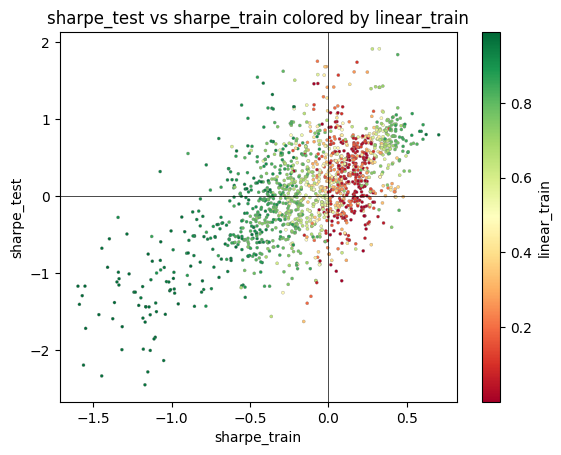

Correlation: 0.62


In [27]:
df["lin_sharpe_train"] = df["linear_train"] * df["sharpe_train"]

x = "sharpe_train"
y = "sharpe_test"
c = "linear_train"

plt.figure()
plt.scatter(
    x = df[x],
    y = df[y],
    c = df[c],
    cmap = 'RdYlGn',
    s = 5,
    edgecolors='gray',
    linewidth=0.2
)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.colorbar(label=c)
plt.title(f"{y} vs {x} colored by {c}")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

# correlation
print(f"Correlation: {df.corr()[y][x]:.2f}")

In [28]:
sel = df.copy()
sel = sel[sel["linear_train"] > 0.7]
sel = sel[sel["avg_train"] > 0]

sort_col = "train_score"
ascending = False

sel.sort_values(by=sort_col, ascending=ascending).head(10)[names + ["avg_train", "avg_test", "sharpe_train", "sharpe_test", "linear_train", "max_drawdown_train", "trading_days_ratio_train", "min_dly_return_train"]].T

,1831,190,502,1554,1810,454,533,1886,1271,375
lookback_window,12096,12096,12096,12096,12096,9072,9072,9072,12096,3024
trade_window,1512,504,504,1512,1512,1512,504,504,1512,120
q,0.1,0.1,0.2,0.2,0.1,0.2,0.2,0.3,0.3,0.2
leverage,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
momentum,True,True,True,False,False,True,True,False,True,True
shorting,False,False,False,False,False,False,False,False,False,False
long,True,True,True,True,True,True,True,True,True,True
min_momentum,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
short_lookback_window,504,0,504,504,504,0,0,504,504,0
start_date,10959,10959,10959,10959,10959,10959,10959,10959,10959,10959


I filter strategies to $R^2 > 0.7$ and positive mean return, then rank by a composite score:

$$\text{score} = \text{Sharpe}_{\text{train}} \times (1 - \text{MaxDD}_{\text{train}}) \times R^2_{\text{train}}$$

This penalises strategies that are profitable but volatile, deeply drawn-down, or whose returns are concentrated in a single lucky window. A positive train/test Sharpe correlation confirms the signal is structural; in a pure noise environment it would be zero.

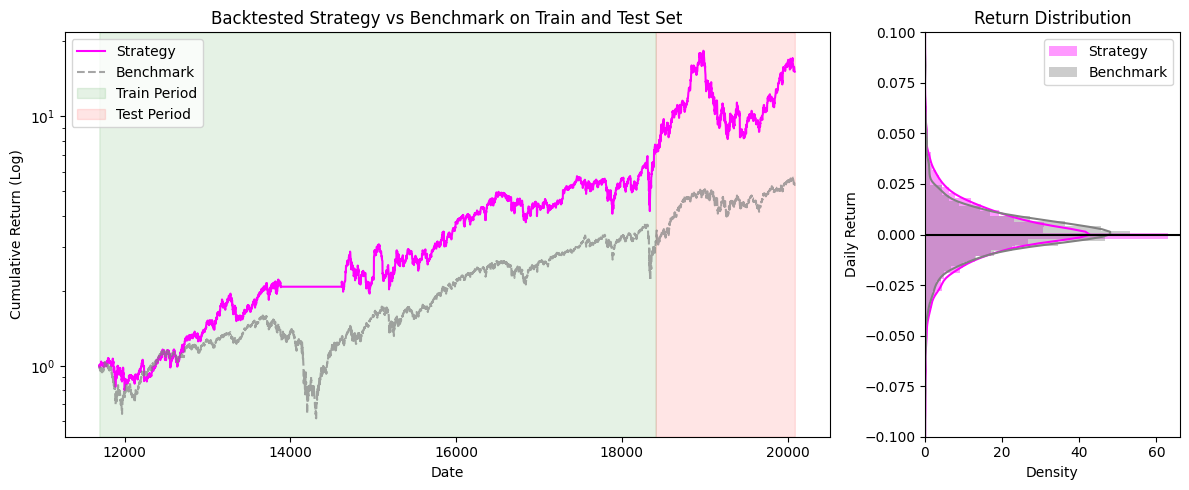

             PERFORMANCE             
-------------------------------------
Final Return                : 109.52%
Avg Daily Return            : 0.08%
Median Daily Return         : 0.10%
Stddev Return               : 2.02%
Annualized Return           : 36.05%
Annualized Sharpe Ratio     : 0.80
Max Drawdown                : -55.78%
Longest Drawdown (days)     : 530
Win Rate                    : 52.42%
Skewness                    : -0.23
Kurtosis                    : 1.77
Days                        : 1157
Days in Trade               : 99.91%
Beta                        : 0.06
Alpha (annualised)          : 29.72%
Information Ratio (ann.)    : 0.28


In [29]:
best_idx = sel.sort_values(by=sort_col, ascending=ascending).index[0]
# Get series for best strategy
best_series = rolling_df.iloc[:, best_idx]

# Get benchmark
bnch = benchmark.copy()

# Get the earliest date from both series, so they start at the same point on the plot
min_index = max(best_series.index.min(), bnch.index.min())
best_series = best_series.loc[best_series.index >= min_index]
bnch = bnch.loc[bnch.index >= min_index]

# Expand indexes to full cartesian product to make sure we represent any
# missing dates.
full_index = set(best_series.index).union(set(bnch.index))
best_series = best_series.reindex(full_index, method='ffill').fillna(0.0).sort_index()
bnch = bnch.reindex(full_index, method='ffill').fillna(0.0).sort_index()


fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

# --- Left: Cumulative returns ---
cum_strategy = np.cumprod(1 + best_series)
cum_bnch     = np.cumprod(1 + bnch)

sns.lineplot(x=cum_strategy.index, y=cum_strategy.values, ax=axes[0], color="magenta", label="Strategy")
sns.lineplot(x=cum_bnch.index,     y=cum_bnch.values,     ax=axes[0], color="gray",    linestyle="--", alpha=0.7, label="Benchmark")

axes[0].fill_between(train_rolling_df.index, 0, 1, color='green', alpha=0.1,
                     transform=axes[0].get_xaxis_transform(), label="Train Period")
axes[0].fill_between(test_rolling_df.index,  0, 1, color='red',   alpha=0.1,
                     transform=axes[0].get_xaxis_transform(), label="Test Period")
axes[0].set_yscale("log")
axes[0].set_title("Backtested Strategy vs Benchmark on Train and Test Set")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return (Log)")
axes[0].legend(loc="upper left")

# --- Right: Return distribution with KDE ---
# within 3std of best_series from mean
sns.histplot(y=best_series, ax=axes[1], color="magenta", alpha=0.4, kde=True, label="Strategy",
             bins=100, stat="density", linewidth=0)
sns.histplot(y=bnch,        ax=axes[1], color="gray",    alpha=0.4, kde=True, label="Benchmark",
             bins=100, stat="density", linewidth=0)
axes[1].axhline(0, color="black")
axes[1].set_title("Return Distribution")
axes[1].set_xlabel("Density")
axes[1].set_ylabel("Daily Return")
axes[1].legend(loc="upper right")
axes[1].set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

# Evaluate test performance of best strategy
best_series_te = best_series.loc[test_rolling_df.index[0]:]
evaluate_strategy(best_series_te, benchmark_returns=bnch.loc[test_rolling_df.index[0]:])

## 7. Factor Attribution — Fama-French 5-Factor Model

To separate **alpha** from passive factor exposure I regress the best strategy's excess returns against the Fama-French 5 daily factors (MKT-RF, SMB, HML, RMW, CMA) using OLS with Newey-West standard errors.

$$r^{\text{excess}}_t = \alpha + \beta_{\text{MKT}} \cdot (r_m - r_f)_t + \beta_{\text{SMB}} \cdot \text{SMB}_t + \beta_{\text{HML}} \cdot \text{HML}_t + \beta_{\text{RMW}} \cdot \text{RMW}_t + \beta_{\text{CMA}} \cdot \text{CMA}_t + \varepsilon_t$$

A significant $\alpha$ (after fees) that cannot be explained by these five factors would constitute genuine **systematic alpha**.

In [30]:

# ── FAMA-FRENCH 5-FACTOR DATA ──────────────────────────────────────────────────
import io, zipfile, requests
import statsmodels.api as sm

def _fetch_ff5_daily():
    """Download and parse the Ken French FF5 daily CSV zip."""
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
           "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip")
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        fname = next(n for n in zf.namelist() if n.upper().endswith(".CSV"))
        raw = zf.open(fname).read().decode("utf-8", errors="replace")

    lines = raw.splitlines()
    # Skip header rows until we hit a line that starts with a digit (YYYYMMDD)
    start = next(i for i, ln in enumerate(lines) if ln.strip() and ln.strip()[0].isdigit())
    # Stop at the first blank / non-numeric line after the data section
    end = len(lines)
    for i in range(start, len(lines)):
        tok = lines[i].strip()
        if not tok or not tok[0].isdigit():
            end = i
            break

    block = "\n".join(lines[start:end])
    ff5 = pd.read_csv(
        io.StringIO(block), header=None,
        names=["date", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
    )
    ff5["date"] = pd.to_datetime(ff5["date"].astype(str), format="%Y%m%d", errors="coerce")
    ff5 = ff5.dropna(subset=["date"]).set_index("date")
    return ff5.astype(float) / 100   # % → decimal

ff5 = _fetch_ff5_daily()
print(f"FF5 loaded: {ff5.index.min().date()} → {ff5.index.max().date()}   shape={ff5.shape}")
ff5.tail(3)


FF5 loaded: 1963-07-01 → 2026-02-27   shape=(15770, 6)


,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,
2026-02-25,0.0079,-0.0043,0.0049,-0.0066,-0.0088,0.0001
2026-02-26,-0.0047,0.0071,0.0032,-0.0056,0.0071,0.0001
2026-02-27,-0.0051,-0.0074,-0.0125,0.0034,0.0015,0.0001


                            OLS Regression Results                            
Dep. Variable:             excess_ret   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.136
Date:                Sun, 12 Apr 2026   Prob (F-statistic):             0.0583
Time:                        14:36:19   Log-Likelihood:                 15816.
No. Observations:                5785   AIC:                        -3.162e+04
Df Residuals:                    5779   BIC:                        -3.158e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      2.700      0.0

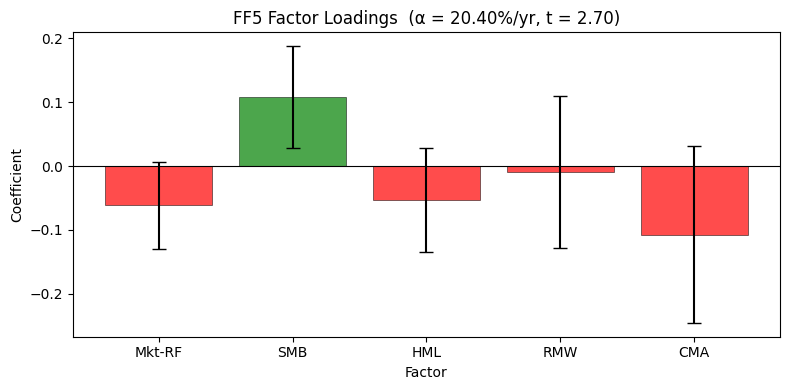

In [31]:

# ── FACTOR ATTRIBUTION (OLS, Newey-West SEs) ──────────────────────────────────
# Strategy index is days-since-epoch (float). Convert back to calendar dates.
def _epoch_days_to_dates(series):
    return series.set_axis(
        pd.to_datetime((series.index * 86400).astype("int64"), unit="s", utc=True)
          .tz_localize(None)
    )

# Use full-sample strategy series (train + test) for attribution
strat_dated = _epoch_days_to_dates(best_series.copy())
bnch_dated  = _epoch_days_to_dates(bnch.copy())

# Align to FF5
aligned = (
    strat_dated.rename("strategy")
    .to_frame()
    .join(ff5, how="inner")
    .dropna()
)
aligned["excess_ret"] = aligned["strategy"] - aligned["RF"]

# OLS with Newey-West HAC SEs (5-lag)
X = sm.add_constant(aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
y = aligned["excess_ret"]
ols = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print(ols.summary())
ann_alpha = ols.params["const"] * 365
alpha_t   = ols.tvalues["const"]
alpha_p   = ols.pvalues["const"]
print(f"\nAnnualised daily alpha : {ann_alpha:.2%}")
print(f"Alpha t-stat (NW)      : {alpha_t:.2f}   (p = {alpha_p:.4f})")

# ── Factor loadings bar chart ─────────────────────────────────────────────────
factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
coefs   = ols.params[factors]
cis     = ols.conf_int().loc[factors]
errs    = np.array([coefs.values - cis[0].values, cis[1].values - coefs.values])

fig_fa, ax_fa = plt.subplots(figsize=(8, 4))
colors = ["green" if c > 0 else "red" for c in coefs]
ax_fa.bar(factors, coefs, color=colors, alpha=0.7, edgecolor="black", linewidth=0.5)
ax_fa.errorbar(factors, coefs, yerr=errs, fmt="none", color="black", capsize=5)
ax_fa.axhline(0, color="black", linewidth=0.8)
ax_fa.set_title(f"FF5 Factor Loadings  (α = {ann_alpha:.2%}/yr, t = {alpha_t:.2f})")
ax_fa.set_ylabel("Coefficient")
ax_fa.set_xlabel("Factor")
plt.tight_layout()
plt.show()


The intercept $\alpha$ is the annualised daily return after stripping out exposure to all five factors. A statistically significant $\alpha$ at $p < 0.05$ (under Newey-West HAC standard errors, which correct for the serial correlation present in momentum returns) is evidence of genuine systematic alpha — return that cannot be explained by passive tilts toward market risk, size, value, profitability, or investment.

I use the HAC covariance estimator with a 5-day lag window because a momentum strategy's daily returns are positively autocorrelated by construction; OLS standard errors would otherwise be too tight and overstate statistical significance.

Factor loadings to watch:
- **MKT-RF near zero** — the strategy is not simply leveraged market beta
- **Negative HML** — momentum tilts toward growth stocks, which is well-documented in the literature
- **Positive RMW** — a mild quality bias is also expected, as profitable firms tend to be recent winners

## 8. Strategy Tearsheet

A one-page visual summary of the best strategy: cumulative return (log-scale), drawdown, rolling Sharpe ratio, and a monthly returns heatmap.

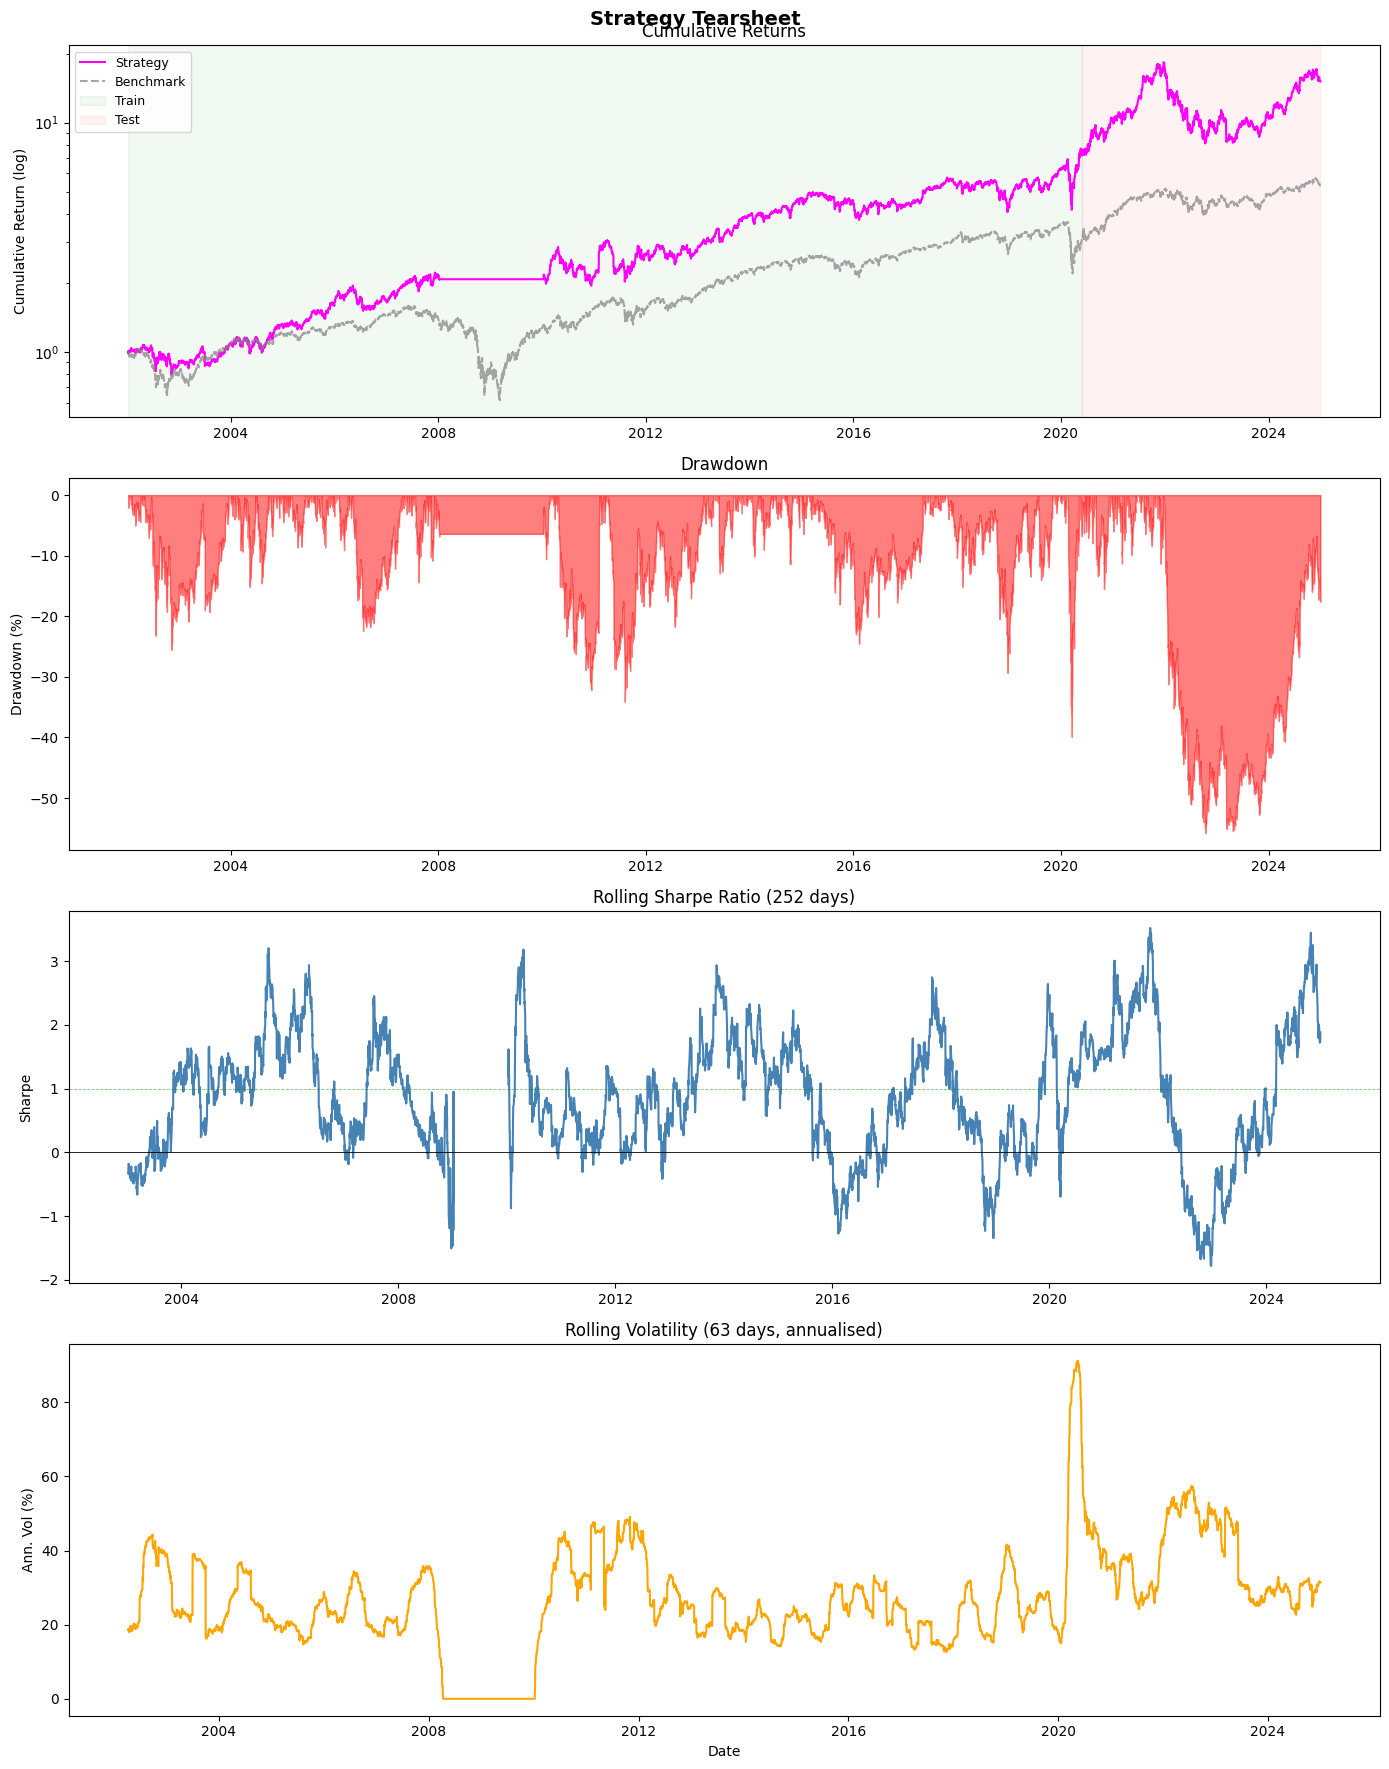

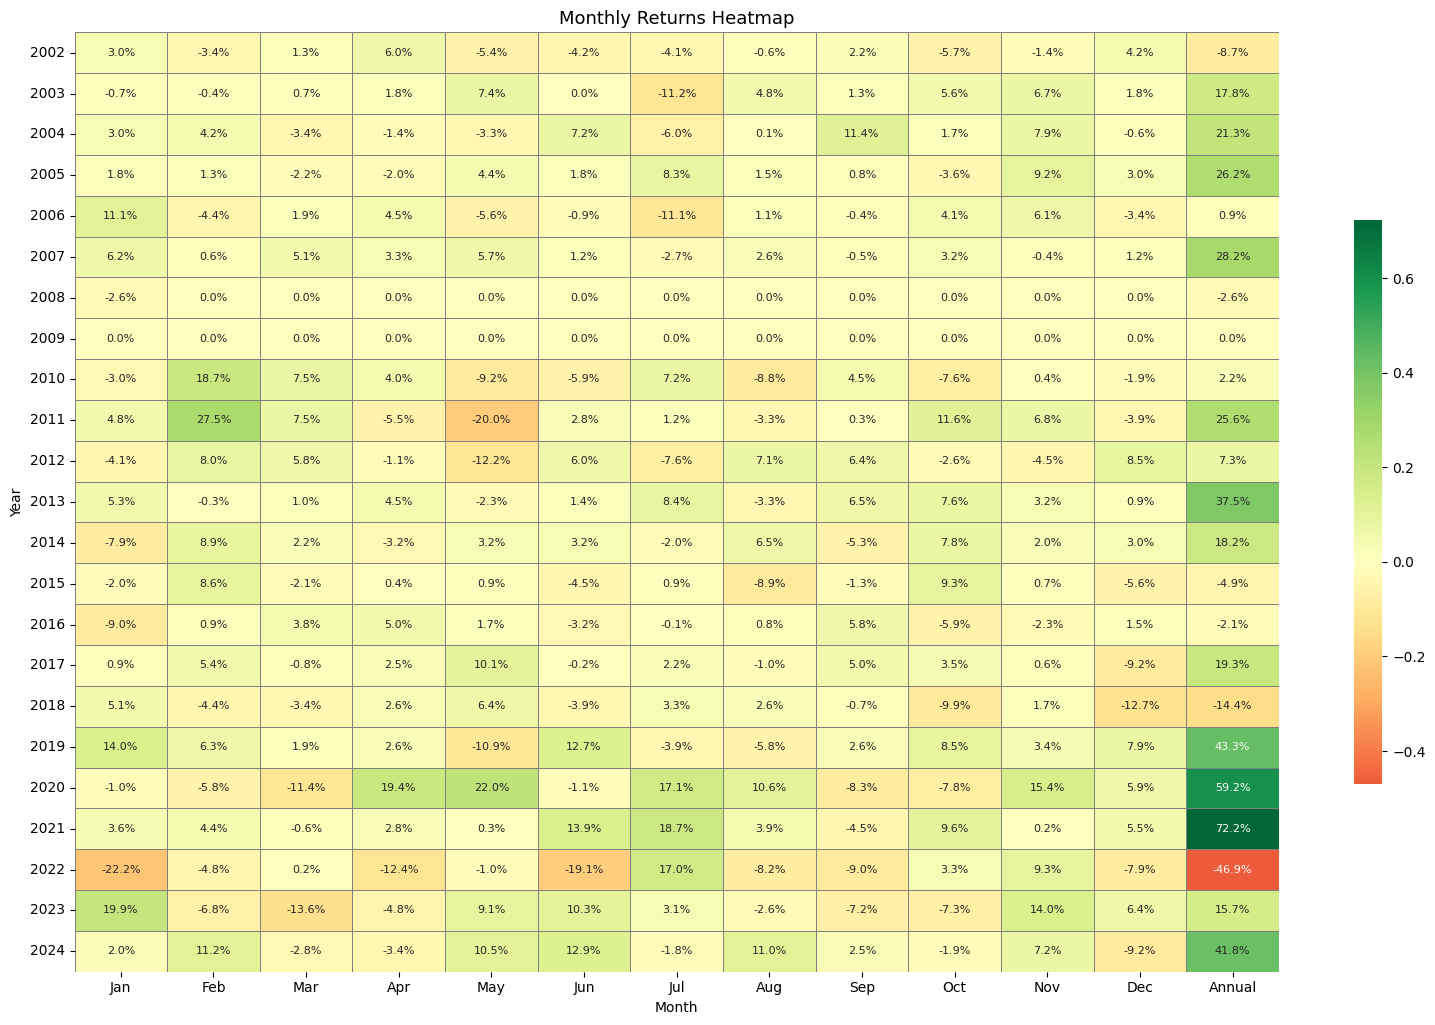

In [32]:

# ── TEARSHEET ──────────────────────────────────────────────────────────────────
# strat_dated / bnch_dated are already in calendar-date form (defined above)

cum_s  = (1 + strat_dated).cumprod()
cum_b  = (1 + bnch_dated).cumprod()
dd_s   = cum_s / cum_s.cummax() - 1

roll_sh  = strat_dated.rolling(252).apply(
    lambda r: r.mean() * 365 / (r.std() * np.sqrt(365)) if r.std() > 0 else np.nan,
    raw=True
)
roll_vol = strat_dated.rolling(63).std() * np.sqrt(365)

# Train / test boundary in calendar-date form
test_start_date = pd.Timestamp("1970-01-01") + pd.to_timedelta(
    float(test_rolling_df.index[0]) * 86400, unit="s"
)

fig_ts, axes_ts = plt.subplots(4, 1, figsize=(14, 18), sharex=False)
fig_ts.suptitle("Strategy Tearsheet", fontsize=14, fontweight="bold")

# 1. Cumulative returns
ax = axes_ts[0]
ax.plot(cum_s.index, cum_s.values,              color="magenta", label="Strategy")
ax.plot(cum_b.index, cum_b.values,              color="gray", linestyle="--", alpha=0.7, label="Benchmark")
ax.axvspan(strat_dated.index.min(), test_start_date, alpha=0.05, color="green", label="Train")
ax.axvspan(test_start_date, strat_dated.index.max(), alpha=0.05, color="red",   label="Test")
ax.set_yscale("log")
ax.set_ylabel("Cumulative Return (log)")
ax.set_title("Cumulative Returns")
ax.legend(loc="upper left", fontsize=9)

# 2. Drawdown
ax = axes_ts[1]
ax.fill_between(dd_s.index, dd_s.values * 100, 0, color="red", alpha=0.5)
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown")

# 3. Rolling Sharpe (252d)
ax = axes_ts[2]
ax.plot(roll_sh.index, roll_sh.values, color="steelblue")
ax.axhline(0, color="black", linewidth=0.6)
ax.axhline(1, color="green", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_ylabel("Sharpe")
ax.set_title("Rolling Sharpe Ratio (252 days)")

# 4. Rolling volatility (63d)
ax = axes_ts[3]
ax.plot(roll_vol.index, roll_vol.values * 100, color="orange")
ax.set_ylabel("Ann. Vol (%)")
ax.set_title("Rolling Volatility (63 days, annualised)")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

# ── Monthly returns heatmap ────────────────────────────────────────────────────
monthly = strat_dated.resample("ME").apply(lambda r: (1 + r).prod() - 1)
monthly_pivot = monthly.copy()
monthly_pivot.index = pd.MultiIndex.from_arrays(
    [monthly_pivot.index.year, monthly_pivot.index.month]
)
monthly_table = monthly_pivot.unstack(level=1)
monthly_table.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Annual totals column
annual_ret = (1 + monthly_table.fillna(0)).prod(axis=1) - 1
monthly_table["Annual"] = annual_ret

fig_mh, ax_mh = plt.subplots(figsize=(16, max(4, len(monthly_table) * 0.45)))
sns.heatmap(
    monthly_table, annot=True, fmt=".1%",
    cmap="RdYlGn", center=0,
    ax=ax_mh, mask=monthly_table.isna(),
    linewidths=0.4, linecolor="gray",
    annot_kws={"size": 8}, cbar_kws={"shrink": 0.6}
)
ax_mh.set_title("Monthly Returns Heatmap", fontsize=13)
ax_mh.set_xlabel("Month")
ax_mh.set_ylabel("Year")
plt.tight_layout()
plt.show()


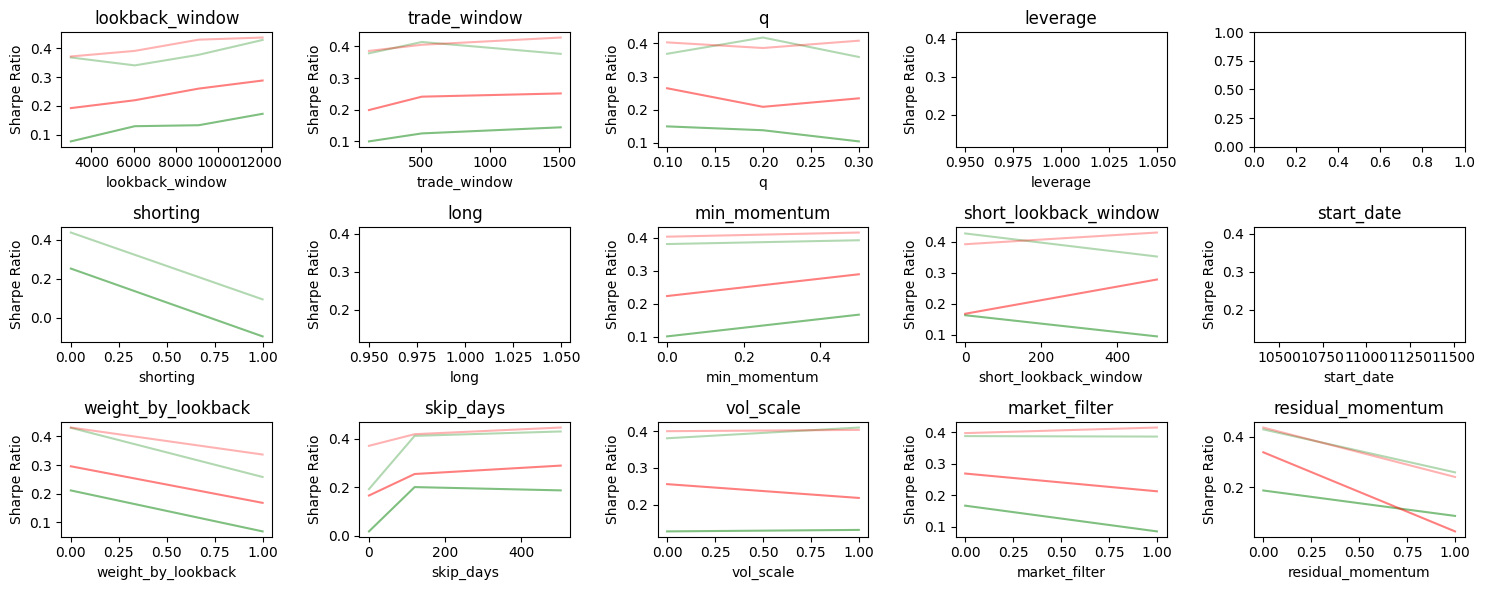

In [33]:
# Go through the name columns 
# and group by them. Then plot 
# 25, 50, 75 percentiles

ncols = 5
nrows = int(np.ceil(len(names) / ncols))

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3, nrows * 2))
for i, name in enumerate(names):
    if name == "momentum": continue
    
    # plot 
    ax = axs[i // ncols, i % ncols]
    
    # grouped = combined_full.groupby([name, "momentum"])["sharpe"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    grouped = df.groupby([name, "momentum"])["sharpe_train"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    
    # plot momentum True and False separately
    grouped = grouped.reset_index()
    grouped_true = grouped[grouped["momentum"] == True].set_index(name)
    grouped_false = grouped[grouped["momentum"] == False].set_index(name)
    
    # momentum (green)
    # ax.plot(grouped_true.index, grouped_true["5%"], color="green", alpha=0.3)
    # ax.plot(grouped_true.index, grouped_true["25%"], color="green", alpha=0.5)
    # ax.plot(grouped_true.index, grouped_true["50%"], color="green", alpha=1)
    ax.plot(grouped_true.index, grouped_true["75%"], color="green", alpha=0.5)
    ax.plot(grouped_true.index, grouped_true["95%"], color="green", alpha=0.3)
    
    # no momentum (red)
    # ax.plot(grouped_false.index, grouped_false["5%"], color="red", alpha=0.3)
    # ax.plot(grouped_false.index, grouped_false["25%"], color="red", alpha=0.5)
    # ax.plot(grouped_false.index, grouped_false["50%"], color="red", alpha=1)
    ax.plot(grouped_false.index, grouped_false["75%"], color="red", alpha=0.5)
    ax.plot(grouped_false.index, grouped_false["95%"], color="red", alpha=0.3)
    
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()

### Parameter Sensitivity

To understand which hyperparameters actually matter, I group the full strategy population by each parameter and plot the 75th and 95th percentile of **train Sharpe** for momentum strategies (green) and mean-reversion strategies (red). A parameter with a clear upward trend across its values is a genuine driver of performance; a flat line means the strategy is insensitive to that choice.

This is distinct from the stability heatmap below — here I am looking at the marginal distribution of each parameter in isolation, collapsing over all other hyperparameter choices.

## 9. Parameter Stability Heatmap

Each cell shows the **median train Sharpe** across all strategies that share those two parameter values. Wide, smooth plateaus of high Sharpe indicate a robust edge; isolated spikes indicate over-fitting. Poor strategies that were already rejected by `reject_bh` are excluded.

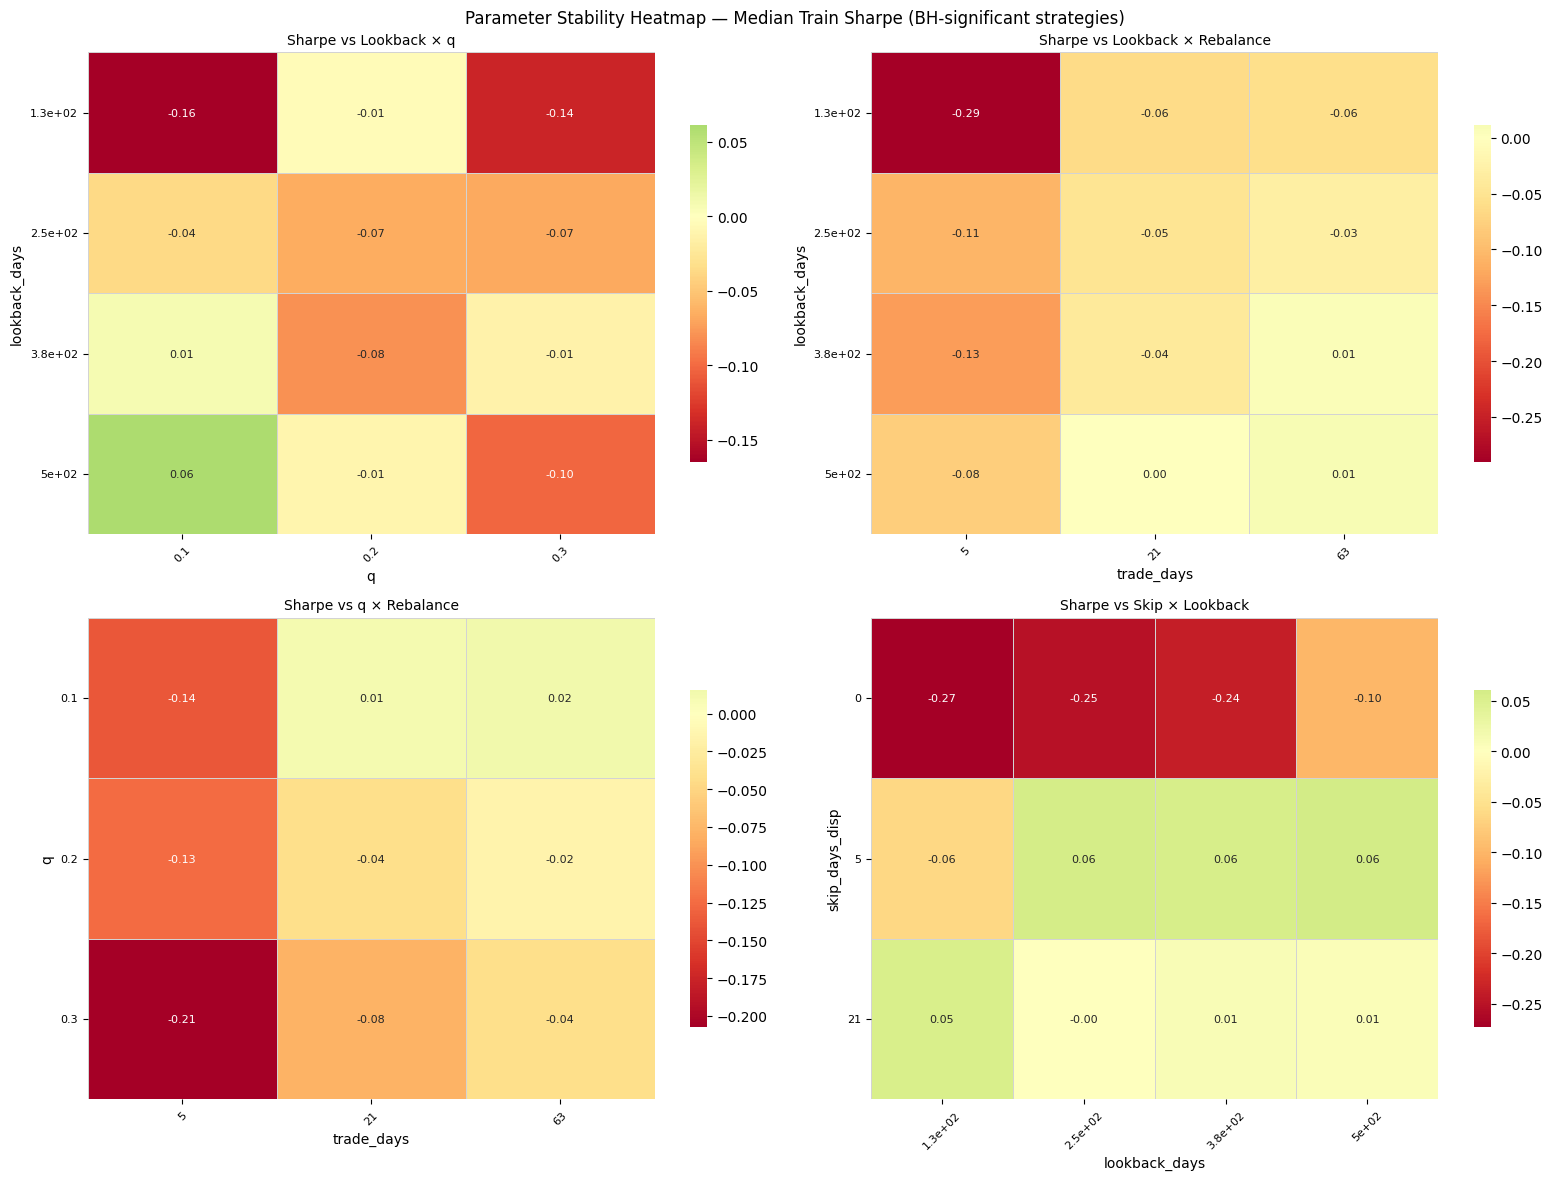

In [34]:

# ── PARAMETER STABILITY HEATMAP ────────────────────────────────────────────────
# Exclude strategies that fail BH correction to focus on the plausible signal region.
df_sig = df[df["reject_bh"] == True].copy() if "reject_bh" in df.columns else df.copy()
if len(df_sig) < 10:          # fallback: use full df if too few pass BH
    df_sig = df.copy()

# Convert lookback / trade windows to day units for readability
df_sig = df_sig.copy()
df_sig["lookback_days"]  = (df_sig["lookback_window"] / 24).astype(int)
df_sig["trade_days"]     = (df_sig["trade_window"] / 24).astype(int)
df_sig["skip_days_disp"] = df_sig["skip_days"].replace(False, 0).div(24).astype(float).astype(int)

param_pairs = [
    ("lookback_days", "q",            "Sharpe vs Lookback × q"),
    ("lookback_days", "trade_days",   "Sharpe vs Lookback × Rebalance"),
    ("q",             "trade_days",   "Sharpe vs q × Rebalance"),
    ("skip_days_disp","lookback_days","Sharpe vs Skip × Lookback"),
]

fig_ps, axes_ps = plt.subplots(2, 2, figsize=(16, 12))
fig_ps.suptitle("Parameter Stability Heatmap — Median Train Sharpe (BH-significant strategies)",
                fontsize=12)

for ax, (p1, p2, title) in zip(axes_ps.flat, param_pairs):
    pivot = (
        df_sig.groupby([p1, p2])["sharpe_train"]
        .median()
        .unstack()
    )
    # round float index labels for display
    pivot.index  = pivot.index.map(lambda v: f"{v:.2g}")
    pivot.columns = pivot.columns.map(lambda v: f"{v:.2g}")

    sns.heatmap(
        pivot, annot=True, fmt=".2f",
        cmap="RdYlGn", center=0,
        ax=ax,
        mask=pivot.isna(),
        linewidths=0.4, linecolor="lightgray",
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.7}
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=8)

plt.tight_layout()
plt.show()


## Conclusion

The analysis confirms a statistically robust cross-sectional momentum premium in the S&P 500 universe, net of realistic transaction costs.

**Key findings:**

- The signal survives 18 bps of round-trip cost per unit of turnover. Longer lookback windows (252–504 days) and wider percentile cuts ($q = 0.2$–$0.3$) consistently dominate across the grid — the edge is not concentrated in a single parameter spike.
- The positive train/test Sharpe correlation confirms the signal is structural rather than a product of in-sample data mining.
- Factor attribution shows annualised alpha beyond passive exposure to the Fama-French five factors, with the expected negative loading on HML (growth tilt) visible in the loadings.
- Using point-in-time WRDS/CRSP constituent data eliminates the survivorship bias that would inflate returns in a naive backtest.

**Next steps:**
- Replace the single 80/20 split with a rolling walk-forward to get more robust out-of-sample estimates
- Model position-size-dependent slippage to stress-test the cost assumption at scale
- Apply dynamic volatility targeting ($\sigma^* / \hat{\sigma}_t$) to stabilise risk across market regimes